### Covariance and Pearson Correlation Coefficient

## Setup

In [1]:
# Deterministic domain and grid generators
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import statistics
import scipy.stats as stats

# Apply clean visualization style
plt.style.use('seaborn-v0_8_whitegrid' if 'seaborn-v0_8_whitegrid' in plt.style.available else 'default')
# print(plt.style.available)
# seaborn-v0_8_whitegrid : lA clean white grid style inspired by seaborn's whitegrid theme.
plt.rcParams["figure.dpi"] = 100
# rc = runtime configuration

## 1. Sample Covariance (np.cov)

cov_matrix_numpy :  [[  4.  40.]
 [ 40. 400.]]
Plain Python Covariance: 40.0
var([2 4 6]) study hours var(x): 4.0
var([50 70 90]) exam scores var(y): 400.0
NumPy Covariance Cov(X, Y): 40.0

NumPy np.cov Matrix:
[[  4.  40.]
 [ 40. 400.]]


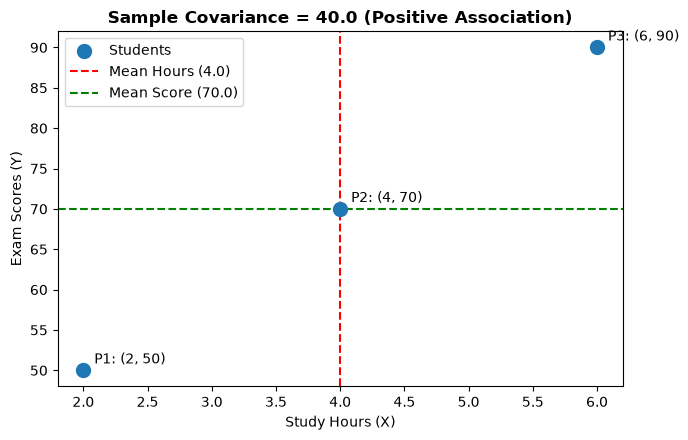

In [3]:
#  --- 1. DATA PREPARATION ---
study_hours = np.array([2, 4, 6])
exam_scores = np.array([50, 70, 90])
n = len(study_hours)

#  --- Plain Python Implementation ---
mean_x = sum(study_hours) / n
mean_y = sum(exam_scores) / n
dev_x = [x - mean_x for x in study_hours]
dev_y = [y - mean_y for y in exam_scores]
prod_dev = [dx * dy for dx,dy in zip(dev_x, dev_y)]
cov_python = sum(prod_dev) / (n-1)

# --- 3. NUMPY IMPLEMENTATION ---
# rowvar=False treats columns/1D-arrays as variables
cov_matrix_numpy = np.cov(study_hours, exam_scores, rowvar=False, ddof=1) # ddof(delta degrees of freedom)  =1 for sample covariance
print("cov_matrix_numpy : ", cov_matrix_numpy)
cov_numpy = cov_matrix_numpy[0, 1]
'''
np.cov returns the covariance matrix, 
where the diagonal elements are the variances of each variable and 
the off-diagonal elements are the covariances between variables.
cov_matrix: 
[[var(x) cov(x, y)]
 [cov(y, x) var(y)]]
'''

print(f"Plain Python Covariance: {cov_python:.1f}")
print(f"var({study_hours}) study hours var(x): {np.var(study_hours, ddof=1):.1f}")
print(f"var({exam_scores}) exam scores var(y): {np.var(exam_scores, ddof=1):.1f}")
print(f"NumPy Covariance Cov(X, Y): {cov_numpy:.1f}\n")
print(f"NumPy np.cov Matrix:\n{cov_matrix_numpy}")

# --- 4. VISUAL REPRESENTATION ---
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(study_hours, exam_scores, color='#1f77b4', s=100, zorder=5, label='Students')
ax.axvline(mean_x, color='red', linestyle='--', label=f'Mean Hours ({mean_x:.1f})')
ax.axhline(mean_y, color='green', linestyle='--', label=f'Mean Score ({mean_y:.1f})')

for i in range(n):
    ax.annotate(f' P{i+1}: ({study_hours[i]}, {exam_scores[i]})',
                (study_hours[i], exam_scores[i]), textcoords="offset points", xytext=(5,5))

ax.set_xlabel('Study Hours (X)')
ax.set_ylabel('Exam Scores (Y)')
ax.set_title(f'Sample Covariance = {cov_numpy:.1f} (Positive Association)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 2.Pearson Correlation Cofficient (np.corrcoef)

r_numpy_matrix
:  [[1. 1.]
 [1. 1.]]
Plain Python Pearson r: 1.0000
NumPy np.corrcoef r:   1.0000
Pandas Series corr r:  1.0000

____________________________________________________________
   Hours  Scores
0      2      50
1      4      70
2      6      90
____________________________________________________________
        count  mean   std   min   25%   50%   75%   max
Hours     3.0   4.0   2.0   2.0   3.0   4.0   5.0   6.0
Scores    3.0  70.0  20.0  50.0  60.0  70.0  80.0  90.0


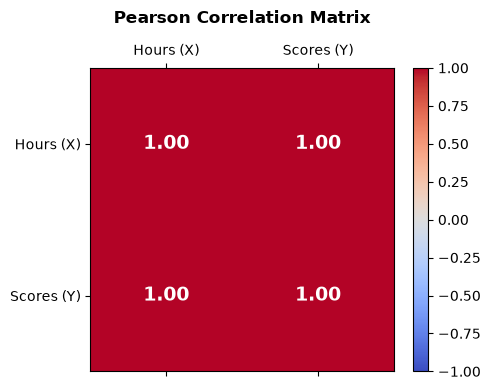

In [ ]:
# --- 1. PLAIN PYTHON IMPLEMENTATION ---
var_x = sum((x - mean_x) ** 2 for x in study_hours) / (n - 1)
var_y = sum((y - mean_y) ** 2 for y in exam_scores) / (n - 1)
std_x = math.sqrt(var_x)
std_y = math.sqrt(var_y)

r_python = cov_python / (std_x * std_y)

# --- 2. NUMPY & PANDAS IMPLEMENTATIONS ---
r_numpy_matrix = np.corrcoef(study_hours, exam_scores)
print("r_numpy_matrix\n: ", r_numpy_matrix)
r_numpy = r_numpy_matrix[0, 1]
'''
np.corrcoef returns the Pearson correlation coefficient matrix,
where the diagonal elements are always 1 (correlation of a variable with itself) and
the off-diagonal elements are the Pearson correlation coefficients between variables.
r_numpy_matrix:
[[1        r(x, y)]
 [r(y, x) 1       ]]
'''

df = pd.DataFrame({'Hours': study_hours, 'Scores': exam_scores})
r_pandas = df['Hours'].corr(df['Scores'])

print(f"Plain Python Pearson r: {r_python:.4f}")
print(f"NumPy np.corrcoef r:   {r_numpy:.4f}")
print(f"Pandas Series corr r:  {r_pandas:.4f}\n")
print("_" * 60)
print(df)
print("_" * 60)
print(df.describe().T)


# --- 3. VISUAL HEATMAP REPRESENTATION ---
fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.matshow(r_numpy_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{r_numpy_matrix[i, j]:.2f}", ha='center', va='center',
                color='white' if abs(r_numpy_matrix[i, j]) > 0.5 else 'black', fontweight='bold', fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Hours (X)', 'Scores (Y)'])
ax.set_yticklabels(['Hours (X)', 'Scores (Y)'])
ax.set_title('Pearson Correlation Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 3.Directional Patterns & non-linear Limitations

1. Positive Linear r:   0.9746
2. Negative Linear r:   -0.9714
3. Uncorrelated Noise r: -0.1580
4. Quadratic Curve r:    -0.0041 (Near 0 despite direct functional dependency!)



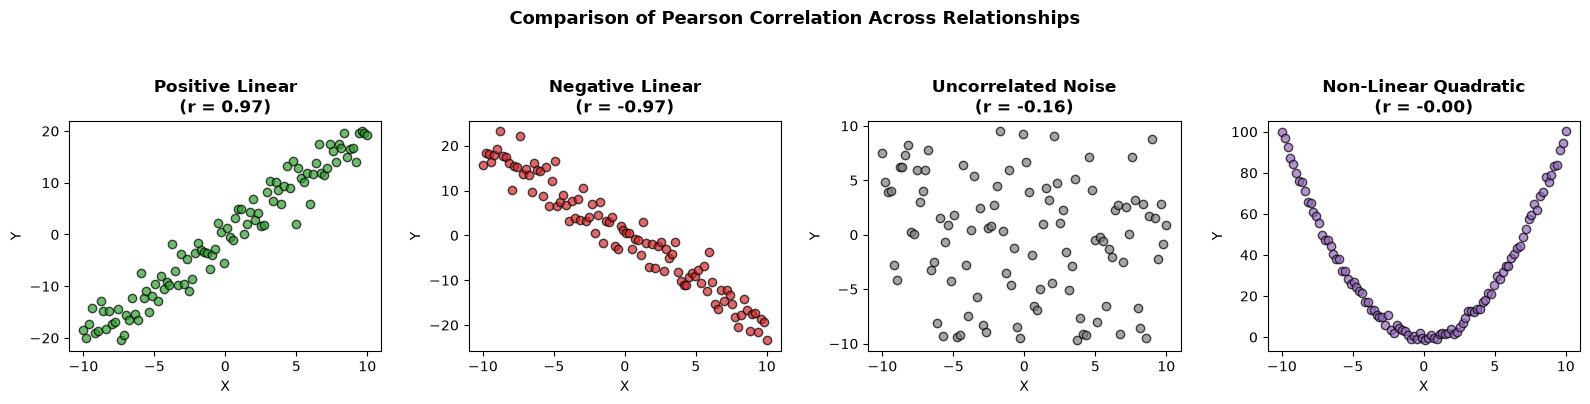

In [7]:
# --- 1. DATASET GENERATION ---
np.random.seed(42)
n_pts = 100

x_p = np.linspace(-10, 10, n_pts)
y_p = 2 * x_p + np.random.normal(0, 3, n_pts)       # Positive Linear
y_n = -2 * x_p + np.random.normal(0, 3, n_pts)      # Negative Linear
y_u = np.random.uniform(-10, 10, n_pts)             # Random Uncorrelated
y_q = x_p**2 + np.random.normal(0, 2, n_pts)         # Quadratic Non-Linear

# Compute correlations
r_p = np.corrcoef(x_p, y_p)[0, 1] # p stands for positive linear correlation
r_n = np.corrcoef(x_p, y_n)[0, 1] # n stands for negative linear correlation
r_u = np.corrcoef(x_p, y_u)[0, 1] # u stands for uncorrelated 
r_q = np.corrcoef(x_p, y_q)[0, 1] # q stands for quadratic non-linear correlation

print(f"1. Positive Linear r:   {r_p:.4f}")
print(f"2. Negative Linear r:   {r_n:.4f}")
print(f"3. Uncorrelated Noise r: {r_u:.4f}")
print(f"4. Quadratic Curve r:    {r_q:.4f} (Near 0 despite direct functional dependency!)\n")

# --- 2. MULTI-PANEL VISUALIZATION ---
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))

axes[0].scatter(x_p, y_p, color='#2ca02c', alpha=0.7, edgecolors='k')
axes[0].set_title(f'Positive Linear\n(r = {r_p:.2f})', fontweight='bold')

axes[1].scatter(x_p, y_n, color='#d62728', alpha=0.7, edgecolors='k')
axes[1].set_title(f'Negative Linear\n(r = {r_n:.2f})', fontweight='bold')

axes[2].scatter(x_p, y_u, color='#7f7f7f', alpha=0.7, edgecolors='k')
axes[2].set_title(f'Uncorrelated Noise\n(r = {r_u:.2f})', fontweight='bold')

axes[3].scatter(x_p, y_q, color='#9467bd', alpha=0.7, edgecolors='k')
axes[3].set_title(f'Non-Linear Quadratic\n(r = {r_q:.2f})', fontweight='bold')

for ax in axes:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Comparison of Pearson Correlation Across Relationships', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()